In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, ConfusionMatrixDisplay

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [12]:
# For when exploring imb techniques
from imblearn.pipeline import Pipeline as imb_Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [ ]:
'''
If using .env
'''
# from pathlib import Path
# from dotenv import find_dotenv, load_dotenv

# ROOT = Path(find_dotenv()).parent
# print(ROOT)
# DATASET_FILE = ROOT / os.getenv("DATASET_PATH")
# print(DATASET_FILE)

In [2]:
import sys
from pathlib import Path

this_file = Path.cwd()
ROOT = Path(this_file).resolve().parent
sys.path.append(str(ROOT))

from app.config import DATASET_FILE


C:\Users\Carl Sebastian\(new) VS_projects\aegis-vanguard-network-attack-detection-system


In [3]:
# Compilation of the 8 csv file from Kaggle
new_data = pd.read_csv(DATASET_FILE, encoding='latin-1')

In [6]:
new_data.columns

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PS

In [10]:
# Comparing whether Fwd Header Length is duplicates or not
print(new_data['Fwd Header Length'].equals(new_data['Fwd Header Length.1']))
print((new_data['Fwd Header Length'] == new_data['Fwd Header Length.1']).all())

True
True


In [13]:
new_data.loc[new_data["Label"] != "BENIGN", "Label"] = "CYBER_ATTACK"

In [14]:
new_data['Label'].value_counts()

Label
BENIGN          2273097
CYBER_ATTACK     557646
Name: count, dtype: int64

In [15]:
X = new_data.drop(columns = ["Label", "Fwd Header Length.1"])
Y = new_data["Label"]

In [16]:
X = pd.DataFrame(
    np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0),
    columns=X.columns,
    index=X.index
)

In [17]:
# Detect inf and nan vals
print(np.isinf(X.values).any())
print(np.isnan(X.values).any()) 

False
False


In [19]:
print(X.columns)
print(len(X.columns))

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PS

In [20]:
# Train-Test-Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.25, stratify = Y_train, random_state=42)


In [21]:
# Preprocessor pipeline (utilized a columntransformer approach because of utilization of imblearn pipeline)
prob_cols = X.columns.tolist()
preprocessor_pipeline = ColumnTransformer(
    transformers=[
        ("numeric",  SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=0), prob_cols)
    ],
    remainder="passthrough"
)


In [22]:
# Encoding the classes for better readability
label_encoder = LabelEncoder()
Y_train = label_encoder.fit_transform(Y_train)
Y_val   = label_encoder.transform(Y_val)
Y_test  = label_encoder.transform(Y_test)

id_to_label = dict(enumerate(label_encoder.classes_))

print(id_to_label)


{0: 'BENIGN', 1: 'CYBER_ATTACK'}


In [23]:
def model_evaluation(pipeline, X_val, Y_val, id_to_label):
    Y_pred = pipeline.predict(X_val)
    Y_pred_proba = pipeline.predict_proba(X_val)[:,1]

    label_keys = list(id_to_label.keys())
    label_values = list(id_to_label.values())
    enc_names = [f"{i}: {id_to_label[i]}" for i in label_keys]

    print(classification_report(
        Y_val,
        Y_pred,
        target_names=enc_names
    ))

    cm = confusion_matrix(Y_val, Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_values)

    plt.figure(figsize=(14, 12))
    disp.plot(xticks_rotation=90, cmap="Blues")
    plt.title("Confusion Matrix (Multi-Class IDS)")
    plt.show()

    print("Micro ROC-AUC:",
          roc_auc_score(Y_val, Y_pred_proba,
                        multi_class="ovr",
                        average="micro"))

    print("Macro ROC-AUC:",
          roc_auc_score(Y_val, Y_pred_proba,
                        multi_class="ovr",
                        average="macro"))

    recalls = recall_score(Y_val, Y_pred, average=None, labels=label_keys)
    recall_df = pd.DataFrame({
        "label": label_values,
        "recall": recalls
    }).sort_values("recall")
    print("\n", recall_df)

                 precision    recall  f1-score   support

      0: BENIGN       1.00      1.00      1.00    454620
1: CYBER_ATTACK       1.00      1.00      1.00    111529

       accuracy                           1.00    566149
      macro avg       1.00      1.00      1.00    566149
   weighted avg       1.00      1.00      1.00    566149



<Figure size 1400x1200 with 0 Axes>

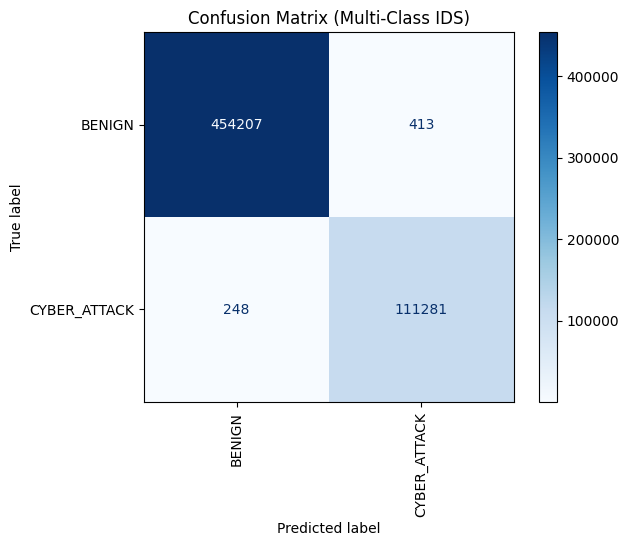

Micro ROC-AUC: 0.9998994420857381
Macro ROC-AUC: 0.9998994420857381

           label    recall
1  CYBER_ATTACK  0.997776
0        BENIGN  0.999092


In [28]:
base_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_pipeline),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs = -1
        ))
    ]
)

base_pipeline.fit(X_train, Y_train)
model_evaluation(base_pipeline, X_val, Y_val, id_to_label)

### SMOTE (Synthetic Minority Oversampling Technique)

Seeing the large imbalance in the dataset and the lacking performance of the above setup, I've decided to use SMOTE. This is so the approach will not just duplicate data but interpolate the other minority samples.

                 precision    recall  f1-score   support

      0: BENIGN       1.00      1.00      1.00    454620
1: CYBER_ATTACK       1.00      1.00      1.00    111529

       accuracy                           1.00    566149
      macro avg       1.00      1.00      1.00    566149
   weighted avg       1.00      1.00      1.00    566149



<Figure size 1400x1200 with 0 Axes>

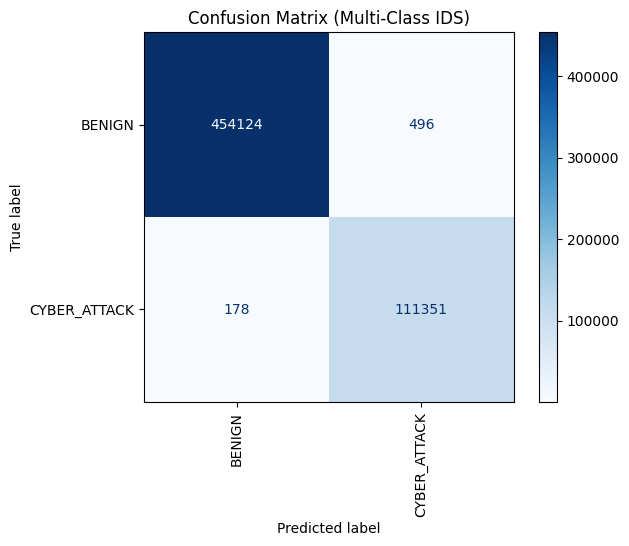

Micro ROC-AUC: 0.9998737375726067
Macro ROC-AUC: 0.9998737375726067

           label    recall
1  CYBER_ATTACK  0.998404
0        BENIGN  0.998909


In [27]:
total_pipeline1 = imb_Pipeline(
    steps=[
        ("preprocessing", preprocessor_pipeline), 
        ("random_sampler", SMOTE(random_state=42)), 
        ("model1", RandomForestClassifier(
                                class_weight=None,
                                  n_jobs=-1,
                                  random_state=42))
    ]
)

total_pipeline1.fit(X_train, Y_train)
model_evaluation(total_pipeline1, X_val, Y_val, id_to_label)


Note: Running K fold Cross Validation might not be a good idea since we have large dataset and have limied computational resources. Simple Train_Test_Split is enough

In [ ]:
from sklearn.model_selection import GridSearchCV

# My laptop couldn't handle this, but if I were to conduct GridSearchCV here, this is my go-to

param_grid = {
    "model1__n_estimators": [int(n) for n in np.linspace(start=100, stop=200, num=2, endpoint=True)], # This is just [100, 200], places it in here so I don't forget
    "model1__max_depth": [5, 10, None],
    "model1__min_samples_split": [3, 5, 7],
    "model1__min_samples_leaf": [1, 3, 5],
}

In [ ]:
tuned_model = GridSearchCV(total_pipeline1, param_grid, scoring='recall', cv=3, n_jobs=-1)
tuned_model.fit(X_train, Y_train)
model_evaluation(tuned_model, X_val, Y_val, id_to_label)

print("Best param", tuned_model.best_params_)

                 precision    recall  f1-score   support

      0: BENIGN       1.00      1.00      1.00    454620
1: CYBER_ATTACK       1.00      1.00      1.00    111529

       accuracy                           1.00    566149
      macro avg       1.00      1.00      1.00    566149
   weighted avg       1.00      1.00      1.00    566149



<Figure size 1400x1200 with 0 Axes>

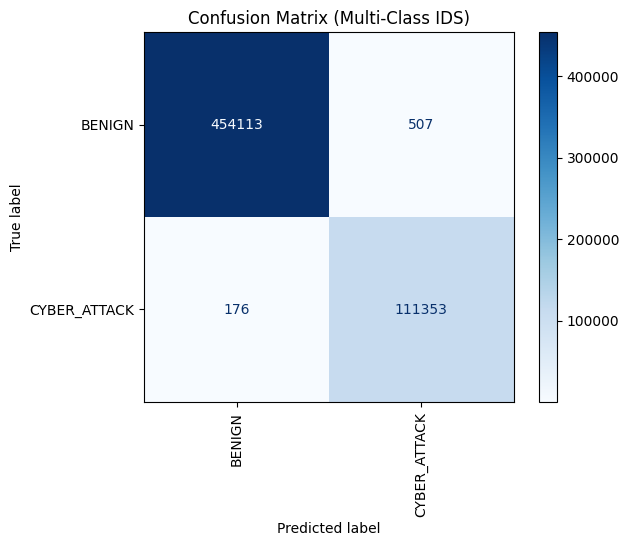

Micro ROC-AUC: 0.9999089040313655
Macro ROC-AUC: 0.9999089040313655

           label    recall
1  CYBER_ATTACK  0.998422
0        BENIGN  0.998885


In [26]:
# Recommendations of ChatGPT since I can't conduct my own GridSearch
total_pipeline2 = imb_Pipeline(
    steps=[
        ("preprocessing", preprocessor_pipeline), 
        ("random_sampler", SMOTE(random_state=42)), 
        ("model1", RandomForestClassifier(n_estimators=100,
                                  max_depth=None,
                                  min_samples_split=5,
                                  min_samples_leaf= 1,
                                  class_weight=None,
                                  n_jobs=-1,
                                  random_state=42))
    ]
)

total_pipeline2.fit(X_train, Y_train)
model_evaluation(total_pipeline2, X_val, Y_val, id_to_label)


### XGboost

Given that the above dataset samples are highly imbalanced, boosting method is the next logical step.

Unlike Random Forest, which builds trees independently, boosting methods train trees **sequentially**, where each new tree focuses on correcting errors made by previous trees. This allows the model to place greater emphasis on difficult-to-classify samples or samples who are eclipsed by the majority.

For this classification task, the objective function `binary:logistic` is used. This configuration outputs a probability of 0 and 1 for the normal and attack classes respectively. Having the latter, allows for probability-based evaluation metrics such as ROC-AUC.

In [24]:
# Having the ff. ratio balances the performance of the model. Refer to documentation accordingly
neg = np.sum(Y_train == 0)
pos = np.sum(Y_train == 1)
ratio = neg / pos

                 precision    recall  f1-score   support

      0: BENIGN       1.00      1.00      1.00    454620
1: CYBER_ATTACK       1.00      1.00      1.00    111529

       accuracy                           1.00    566149
      macro avg       1.00      1.00      1.00    566149
   weighted avg       1.00      1.00      1.00    566149



<Figure size 1400x1200 with 0 Axes>

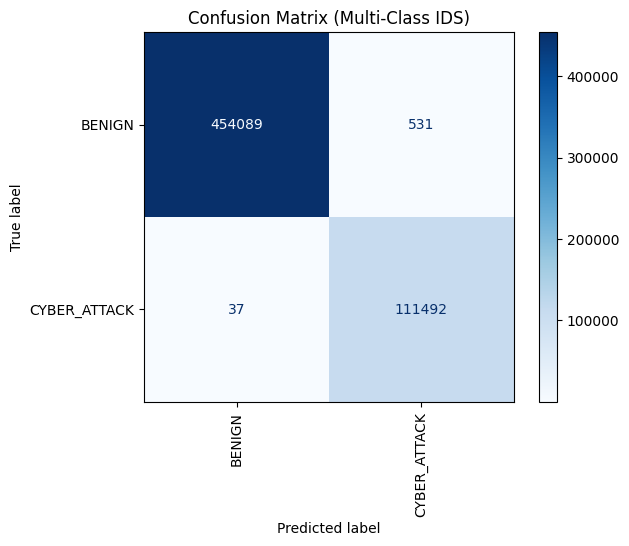

Micro ROC-AUC: 0.9999744419270008
Macro ROC-AUC: 0.9999744419270008

           label    recall
0        BENIGN  0.998832
1  CYBER_ATTACK  0.999668


In [ ]:
total_pipeline3 = Pipeline(
    steps=[
        ("preprocessing", preprocessor_pipeline),
        ("xgb_model", xgb.XGBClassifier(
            n_estimators=400, 
            learning_rate=0.1, # Step size shrinkage. Lower = slow learning, but stable. 0.01-0.1 is standard
            max_depth=6, # Conventional sweetspot per sources
            subsample=0.8, # Basically use 80 percent of the rows per tree
            colsample_bytree=0.8, # Basically use 80 percent of the features per tree
            gamma=0.1, 
            min_child_weight=3,
            scale_pos_weight=ratio, # = (#negative / #positive)
            objective="binary:logistic", # because we are doing binary classification
            eval_metric="auc", # Evaluation metrics
            tree_method="hist", # To use CPU acceleration
            random_state=42,
            n_jobs=-1
        ))
    ]
)

total_pipeline3.fit(X_train, Y_train)
model_evaluation(total_pipeline3, X_val, Y_val, id_to_label)



In [ ]:
Y_pred = total_pipeline3.predict(X_val)
Y_pred_proba = total_pipeline3.predict_proba(X_val)[:,1]

In [ ]:
# FPR: The proportion of negative samples that are incorrectly classified as positive. Basically, false alarms
# FNR: The proportion of positive samples that are incorrectly classified as negative. Basically, faulty detection
TN, FP, FN, TP = confusion_matrix(Y_val, Y_pred).ravel()

FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

print("FPR:", FPR)
print("FNR:", FNR)

In [ ]:
# For adjusting thresholds. Source: GPT
thresholds = np.arange(0.1, 0.95, 0.05)

for t in thresholds:
    Y_pred_t = (Y_pred_proba > t).astype(int)
    TN, FP, FN, TP = confusion_matrix(Y_val, Y_pred_t).ravel()
    
    FPR = FP / (FP + TN)
    FNR = FN / (FN + TP)
    
    print(f"Threshold: {t:.2f} | FPR: {FPR:.6f} | FNR: {FNR:.6f}")

### Finalization

In [31]:
import joblib

final_model = total_pipeline3

joblib.dump(final_model, "layer1_xgb_pipeline.pkl")


['layer1_xgb_pipeline.pkl']